In [61]:
#이전에 trimming 안한 데이터로 rRNA제거해버려서 옆에 파일들 삭제해도됨 - non_rRNA.fastq  GRCm39.mapped.sam  GRCm39.mapped.sorted.bam  GRCm39_read_counts.txt
#!bowtie2 -x rRna_index -U SRR2057648.fastq -S aligned.sam --un non_rRNA.fastq

In [ ]:
## 데이터 전처리 및 정렬 ##

#✅ 1. GTF 압축 해제
!gunzip gencode.vM37.annotation.gtf.gz

In [ ]:
#✅ 2. bowtie2 설치
!sudo apt install bowtie2
# → rRNA 제거를 위해 bowtie2 정렬 도구 설치

In [ ]:
#✅ 3. 마우스 rRNA 서열을 인덱싱 (rRNA 제거용)
!bowtie2-build mouse_rRNA.fa rRna_index
# → rRNA 시퀀스를 인덱스로 변환해서 bowtie2로 검색 가능하게 준비

In [ ]:
#✅ 4. 유전체 FASTA 압축 해제
!gunzip GRCm39.primary_assembly.genome.fa.gz

In [12]:
#✅ 5. GRCm39 유전체 HISAT2 인덱스 생성
!hisat2-build GRCm39.primary_assembly.genome.fa GRCm39.primary_assembly.genome_index

Settings:
  Output files: "GRCm39.primary_assembly.genome_index.*.ht2"
  Line rate: 6 (line is 64 bytes)
  Lines per side: 1 (side is 64 bytes)
  Offset rate: 4 (one in 16)
  FTable chars: 10
  Strings: unpacked
  Local offset rate: 3 (one in 8)
  Local fTable chars: 6
  Local sequence length: 57344
  Local sequence overlap between two consecutive indexes: 1024
  Endianness: little
  Actual local endianness: little
  Sanity checking: disabled
  Assertions: disabled
  Random seed: 0
  Sizeofs: void*:8, int:4, long:8, size_t:8
Input files DNA, FASTA:
  GRCm39.primary_assembly.genome.fa
Reading reference sizes
  Time reading reference sizes: 00:00:33
Calculating joined length
Writing header
Reserving space for joined string
Joining reference sequences
  Time to join reference sequences: 00:00:19
  Time to read SNPs and splice sites: 00:00:00
Using parameters --bmax 497741584 --dcv 1024
  Doing ahead-of-time memory usage test
  Passed!  Constructing with these parameters: --bmax 497741584 

In [ ]:
# Exercise ✅ 6. Exercise 데이터 FASTQ 압축 해제 단계
!gunzip SRR2057648.fastq.gz

In [1]:
# Contorl ✅ 6. Control 데이터 FASTQ 압축 해제 단계
!gunzip SRR2057646.fastq.gz

In [39]:
#Exercise ✅ 6. fastp를 이용한 read 품질 필터링 (trimming)
import subprocess

subprocess.run([
    "fastp",
    "-i", "SRR2057648.fastq",
    "-o", "trimmed_SRR2057648.fastq",
    "-q", "20",
    "-l", "25",
    "-h", "fastp_report_exercise.html"
])
# → 낮은 품질의 read를 제거하고, 분석에 적합한 read만 추림

Detecting adapter sequence for read1...
AGGGCACCACCAGGAGTGGAGCCTGCGGCTTAATTTG

Read1 before filtering:
total reads: 3565792
total bases: 104708331
Q20 bases: 99050272(94.5964%)
Q30 bases: 99050272(94.5964%)

Read1 after filtering:
total reads: 3333170
total bases: 97963669
Q20 bases: 97963669(100%)
Q30 bases: 97963669(100%)

Filtering result:
reads passed filter: 3333170
reads failed due to low quality: 188207
reads failed due to too many N: 0
reads failed due to too short: 44415
reads with adapter trimmed: 8364
bases trimmed due to adapters: 63266

Duplication rate (may be overestimated since this is SE data): 25.1515%

JSON report: fastp.json
HTML report: fastp_report_exercise.html

fastp -i SRR2057648.fastq -o trimmed_SRR2057648.fastq -q 20 -l 25 -h fastp_report_exercise.html 
fastp v0.20.1, time used: 6 seconds


CompletedProcess(args=['fastp', '-i', 'SRR2057648.fastq', '-o', 'trimmed_SRR2057648.fastq', '-q', '20', '-l', '25', '-h', 'fastp_report_exercise.html'], returncode=0)

In [2]:
#Control ✅ 6. fastp를 이용한 read 품질 필터링 (trimming)
import subprocess

subprocess.run([
    "fastp",
    "-i", "SRR2057646.fastq",
    "-o", "trimmed_SRR2057646.fastq",
    "-q", "20",
    "-l", "25",
    "-h", "fastp_report_contrl.html"
])
# → 낮은 품질의 read를 제거하고, 분석에 적합한 read만 추림

Detecting adapter sequence for read1...
No adapter detected for read1

Read1 before filtering:
total reads: 2743301
total bases: 82639361
Q20 bases: 75746021(91.6585%)
Q30 bases: 75746021(91.6585%)

Read1 after filtering:
total reads: 2498635
total bases: 75292037
Q20 bases: 75292037(100%)
Q30 bases: 75292037(100%)

Filtering result:
reads passed filter: 2498635
reads failed due to low quality: 225750
reads failed due to too many N: 0
reads failed due to too short: 18916
reads with adapter trimmed: 0
bases trimmed due to adapters: 0

Duplication rate (may be overestimated since this is SE data): 18.6644%

JSON report: fastp.json
HTML report: fastp_report_contrl.html

fastp -i SRR2057646.fastq -o trimmed_SRR2057646.fastq -q 20 -l 25 -h fastp_report_contrl.html 
fastp v0.20.1, time used: 4 seconds


CompletedProcess(args=['fastp', '-i', 'SRR2057646.fastq', '-o', 'trimmed_SRR2057646.fastq', '-q', '20', '-l', '25', '-h', 'fastp_report_contrl.html'], returncode=0)

In [40]:
#Exercise ✅ 7. rRNA read 제거: bowtie2로 정렬되지 않은 read만 추출 
!bowtie2 -x rRna_index -U trimmed_SRR2057648.fastq -S SRR2057648_rRNA.sam --un non_rRNA_SRR2057648.fastq
# → rRNA 인덱스에 정렬 시도
# → 정렬되지 않은 read (즉, rRNA가 아닌 read)를 non_rRNA_SRR2057648.fastq에 저장

3333170 reads; of these:
  3333170 (100.00%) were unpaired; of these:
    3314684 (99.45%) aligned 0 times
    89 (0.00%) aligned exactly 1 time
    18397 (0.55%) aligned >1 times
0.55% overall alignment rate


In [3]:
#Contorl ✅ 7. rRNA read 제거: bowtie2로 정렬되지 않은 read만 추출 
!bowtie2 -x rRna_index -U trimmed_SRR2057646.fastq -S SRR2057646_rRNA.sam --un non_rRNA_SRR2057646.fastq
# → rRNA 인덱스에 정렬 시도
# → 정렬되지 않은 read (즉, rRNA가 아닌 read)를 non_rRNA_SRR2057646.fastq에 저장

2498635 reads; of these:
  2498635 (100.00%) were unpaired; of these:
    2483334 (99.39%) aligned 0 times
    147 (0.01%) aligned exactly 1 time
    15154 (0.61%) aligned >1 times
0.61% overall alignment rate


In [46]:
#Exercise ✅ 8. rRNA 제거된 Ribo-seq read를 GRCm39에 정렬
!hisat2 -p 8 -x GRCm39.primary_assembly.genome_index -U  non_rRNA_SRR2057648.fastq -S SRR2057648.mapped.sam

3314684 reads; of these:
  3314684 (100.00%) were unpaired; of these:
    1009257 (30.45%) aligned 0 times
    1430090 (43.14%) aligned exactly 1 time
    875337 (26.41%) aligned >1 times
69.55% overall alignment rate


In [4]:
#Control ✅ 8. rRNA 제거된 Ribo-seq read를 GRCm39에 정렬
!hisat2 -p 8 -x GRCm39.primary_assembly.genome_index -U  non_rRNA_SRR2057646.fastq -S SRR2057646.mapped.sam

2483334 reads; of these:
  2483334 (100.00%) were unpaired; of these:
    983725 (39.61%) aligned 0 times
    995688 (40.09%) aligned exactly 1 time
    503921 (20.29%) aligned >1 times
60.39% overall alignment rate


In [48]:
#Exercise ✅ 12. SAM 파일을 BAM 형식으로 정렬 및 변환
!samtools sort -@ 4 \-o SRR2057648.mapped.sorted.bam \SRR2057648.mapped.sam

[bam_sort_core] merging from 0 files and 4 in-memory blocks...


In [5]:
#Control ✅ 12. SAM 파일을 BAM 형식으로 정렬 및 변환
!samtools sort -@ 4 \-o SRR2057646.mapped.sorted.bam \SRR2057646.mapped.sam

[bam_sort_core] merging from 0 files and 4 in-memory blocks...


In [49]:
!ls -lh SRR2057648.mapped.sorted.bam

-rwxrwxrwx 1 moon moon 42M Jun  6 00:34 SRR2057648.mapped.sorted.bam


In [6]:
!ls -lh SRR2057646.mapped.sorted.bam

-rwxrwxrwx 1 moon moon 30M Jun  6 17:00 SRR2057646.mapped.sorted.bam


In [50]:
#Exercise ✅ 13. 정렬된 BAM 파일 확인
!samtools flagstat SRR2057648.mapped.sorted.bam

5241407 + 0 in total (QC-passed reads + QC-failed reads)
3314684 + 0 primary
1926723 + 0 secondary
0 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
4232150 + 0 mapped (80.74% : N/A)
2305427 + 0 primary mapped (69.55% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


In [7]:
#Contorl ✅ 13. 정렬된 BAM 파일 확인
!samtools flagstat SRR2057646.mapped.sorted.bam

3488955 + 0 in total (QC-passed reads + QC-failed reads)
2483334 + 0 primary
1005621 + 0 secondary
0 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
2505230 + 0 mapped (71.80% : N/A)
1499609 + 0 primary mapped (60.39% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


In [32]:
#✅ 14. GTF 파일 압축 해제
!gunzip gencode.vM37.annotation.gtf.gz

In [7]:
#Exercise ✅ 15. featureCounts로 gene별 read 수 계산
!featureCounts \-a gencode.vM37.annotation.gtf \-o SRR2057648_read_counts.txt \SRR2057648.mapped.sorted.bam


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.1

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 1 BAM file                                       ||
||                           o SRR2057648.mapped.sorted.bam                   ||
||                                                                            ||
||             Output file : SRR2057648_read_counts.txt                       ||
||                 Summary : SRR2057648_read_counts.txt.summary  

In [8]:
#Exercise ✅ 15. featureCounts로 gene별 read 수 계산
!featureCounts \-a gencode.vM37.annotation.gtf \-o SRR2057646_read_counts.txt \SRR2057646.mapped.sorted.bam


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.1

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 1 BAM file                                       ||
||                           o SRR2057646.mapped.sorted.bam                   ||
||                                                                            ||
||             Output file : SRR2057646_read_counts.txt                       ||
||                 Summary : SRR2057646_read_counts.txt.summary  

In [36]:
import pandas as pd

# Ribo-seq 기반 read count 데이터 로드
exercise_rpf = pd.read_csv("SRR2057648_read_counts.txt", sep='\t', comment='#', index_col=0)
control_rpf = pd.read_csv("SRR2057646_read_counts.txt", sep='\t', comment='#', index_col=0)

# RPF 값 추출
exercise_rpf['RPF'] = exercise_rpf['SRR2057648.mapped.sorted.bam']
control_rpf['RPF'] = control_rpf['SRR2057646.mapped.sorted.bam']

# 결과 확인
print(exercise_rpf[['RPF']].head())
print(control_rpf[['RPF']].head())

                      RPF
Geneid                   
ENSMUSG00000102693.2    0
ENSMUSG00000064842.3    0
ENSMUSG00000051951.6    0
ENSMUSG00000102851.2    0
ENSMUSG00000103377.2    0
                      RPF
Geneid                   
ENSMUSG00000102693.2    0
ENSMUSG00000064842.3    0
ENSMUSG00000051951.6    0
ENSMUSG00000102851.2    0
ENSMUSG00000103377.2    0


In [37]:
# RPF 값의 분포 확인
print(exercise_rpf['RPF'].describe())  # 기초 통계 정보 확인
print(exercise_rpf['RPF'].value_counts())  # 특정 값 빈도 확인

count     78258.000000
mean         15.707225
std        1682.595804
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      391679.000000
Name: RPF, dtype: float64
RPF
0       65596
1        2311
2        1321
3        1044
4         791
        ...  
2906        1
1084        1
712         1
272         1
2006        1
Name: count, Length: 383, dtype: int64


In [51]:
import pandas as pd

# 데이터 로드
exercise_rpf = pd.read_csv("SRR2057648_read_counts.txt", sep='\t', comment='#', index_col=0)
control_rpf = pd.read_csv("SRR2057646_read_counts.txt", sep='\t', comment='#', index_col=0)

# 'RPF' 값을 실제 BAM 파일 읽기 수로 지정
exercise_rpf['RPF'] = exercise_rpf['SRR2057648.mapped.sorted.bam']
control_rpf['RPF'] = control_rpf['SRR2057646.mapped.sorted.bam']

# 유전자 길이 확인 (Length 열 존재 여부)
exercise_rpf['Length'] = exercise_rpf['Length']
control_rpf['Length'] = control_rpf['Length']

# RPK (Reads Per Kilobase) 계산
exercise_rpf['RPK'] = exercise_rpf['RPF'] / (exercise_rpf['Length'] / 1000)
control_rpf['RPK'] = control_rpf['RPF'] / (control_rpf['Length'] / 1000)

# 전체 샘플 RPK 합 계산
sum_rpk_exercise = exercise_rpf['RPK'].sum()
sum_rpk_control = control_rpf['RPK'].sum()

# TPM 정규화 수행
exercise_rpf['TPM'] = (exercise_rpf['RPK'] / sum_rpk_exercise) * 1e6
control_rpf['TPM'] = (control_rpf['RPK'] / sum_rpk_control) * 1e6

# 결과 확인
print(exercise_rpf[['RPF', 'RPK', 'TPM']].head())
print(control_rpf[['RPF', 'RPK', 'TPM']].head())

                      RPF  RPK  TPM
Geneid                             
ENSMUSG00000102693.2    0  0.0  0.0
ENSMUSG00000064842.3    0  0.0  0.0
ENSMUSG00000051951.6    0  0.0  0.0
ENSMUSG00000102851.2    0  0.0  0.0
ENSMUSG00000103377.2    0  0.0  0.0
                      RPF  RPK  TPM
Geneid                             
ENSMUSG00000102693.2    0  0.0  0.0
ENSMUSG00000064842.3    0  0.0  0.0
ENSMUSG00000051951.6    0  0.0  0.0
ENSMUSG00000102851.2    0  0.0  0.0
ENSMUSG00000103377.2    0  0.0  0.0


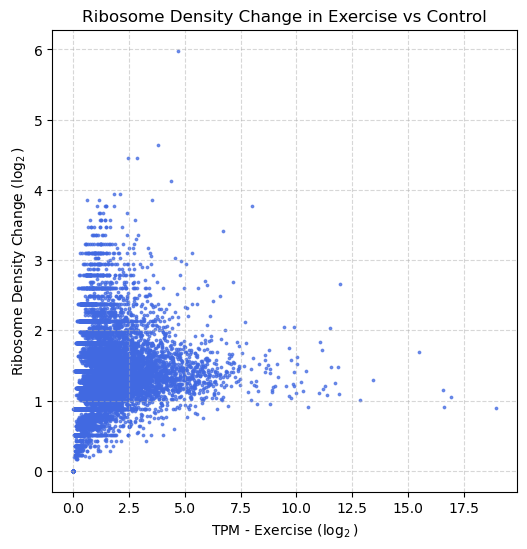

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# 밀도 변화 계산
exercise_rpf['ribosome_density_change'] = exercise_rpf['TPM'] / control_rpf['TPM']

# 로그 변환 적용 (데이터 가독성 개선)
log_density_change = np.log2(exercise_rpf['ribosome_density_change'] + 1)

# 산점도 그래프 생성
plt.figure(figsize=(6, 6))
plt.scatter(np.log2(exercise_rpf['TPM'] + 1), log_density_change, s=3, alpha=0.7, color='royalblue')

# 그래프 설정
plt.xlabel(r"TPM - Exercise ($\log_2$)")
plt.ylabel(r"Ribosome Density Change ($\log_2$)")
plt.title("Ribosome Density Change in Exercise vs Control")
plt.grid(True, linestyle='--', alpha=0.5)

# 그래프 출력
plt.show()

In [ ]:
import pandas as pd
from mygene import MyGeneInfo

# 1️⃣ Uniprot localization 데이터 불러오기
uniprot_df = pd.read_csv("uniprotkb_Mus_musculus_Mouse_2025_06_05.tsv", sep='\t')

# 2️⃣ Gene Symbol 정리 후 필요한 데이터 선택
uniprot_genes = uniprot_df[['Gene Names', 'Subcellular location [CC]']].copy()
uniprot_genes.rename(columns={'Gene Names': 'symbol'}, inplace=True)
uniprot_genes['symbol'] = uniprot_genes['symbol'].str.split().str[0]  # 첫 번째 심볼만 선택

# 3️⃣ Ensembl ID → Gene Symbol 변환
mg = MyGeneInfo()
ensembl_ids_simple = [gid.split('.')[0] for gid in exercise_rpf.index]
symbol_map = mg.querymany(ensembl_ids_simple, scopes='ensembl.gene', fields='symbol', species='mouse')

# 4️⃣ 유효한 결과만 추출 후 DataFrame 변환
symbol_map_valid = [entry for entry in symbol_map if 'symbol' in entry and 'query' in entry]
symbol_df = pd.DataFrame(symbol_map_valid)[['query', 'symbol']].drop_duplicates()

# 5️⃣ 리보솜 밀도 변화 데이터에 Gene Symbol 병합
exercise_rpf['Geneid_simple'] = exercise_rpf.index.str.split('.').str[0]
exercise_rpf = exercise_rpf.merge(symbol_df, left_on='Geneid_simple', right_on='query', how='left')

# 6️⃣ Localization 정보 병합 (Gene Symbol 기준)
merged_data = exercise_rpf.merge(uniprot_genes, on='symbol', how='left')

# 7️⃣ Localization 정보가 있는 유전자만 필터링
filtered_data = merged_data.dropna(subset=['Subcellular location [CC]'])

# 8️⃣ 결과 확인
print(filtered_data.head())

In [ ]:
# 중복된 유전자 정리
filtered_data.drop_duplicates(subset=['symbol'], inplace=True)

# Localization 정보 정리 (핵심 위치만 추출)
filtered_data['location_type'] = filtered_data['Subcellular location [CC]'].str.extract(r'(\bNucleus\b|\bCytoplasm\b|\bMitochondrion\b|\bMembrane\b)')

# 확인 후 결과 출력
print(filtered_data[['symbol', 'location_type']])

<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_17234/549176592.py:27: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('TPM - Exercise($\log_2$)', fontsize=12)
/tmp/ipykernel_17234/549176592.py:28: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('Ribosome Density Change($\log_2$)', fontsize=12)
/tmp/ipykernel_17234/549176592.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['location_type'] = filtered_data['Subcellular location [CC]'].str.extract(r'(\bNucleus\b|\bCytoplasm\b|\bMitochondrion\b)')
/tmp/ipykernel_17234/549176592.py:9: Setting

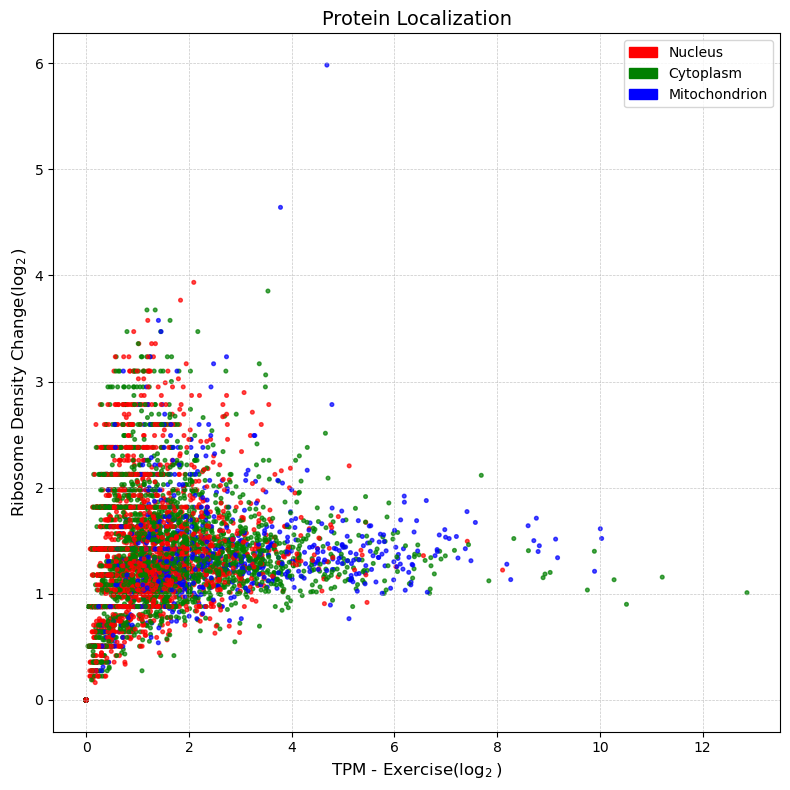

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 정확한 Localization 정보 추출
filtered_data['location_type'] = filtered_data['Subcellular location [CC]'].str.extract(r'(\bNucleus\b|\bCytoplasm\b|\bMitochondrion\b)')

# NaN 값 제거 (Localization 정보가 없는 항목 제외)
filtered_data.dropna(subset=['location_type'], inplace=True)

# **색상 팔레트 정의 및 색상 매핑**
palette = {
    'Nucleus': 'red',           # 핵
    'Cytoplasm': 'green', # 세포질
    'Mitochondrion': 'blue',    # 미토콘드리아
}
colors = filtered_data['location_type'].map(palette)

# 스캐터 플롯 그리기
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(np.log2(filtered_data['TPM'] + 1), 
           np.log2(filtered_data['ribosome_density_change'] + 1),
           c=colors, s=7, alpha=0.7)  # 점 크기 조정

# 레이블 추가
ax.set_xlabel('TPM - Exercise($\log_2$)', fontsize=12)
ax.set_ylabel('Ribosome Density Change($\log_2$)', fontsize=12)
ax.set_title('Protein Localization', fontsize=14)

# 그리드 설정
ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, alpha=0.7)

# **더 명확한 색상 범례 추가**
nucleus_patch = mpatches.Patch(color='red', label='Nucleus')
cytoplasm_patch = mpatches.Patch(color='green', label='Cytoplasm')
mitochondrion_patch = mpatches.Patch(color='blue', label='Mitochondrion')
ax.legend(handles=[nucleus_patch, cytoplasm_patch, mitochondrion_patch], loc='best')

# 레이아웃 정리
plt.tight_layout()

# 시각화 표시
plt.show()

In [71]:
# 밀도 변화가 가장 높은 10개 유전자 선택
top_5_genes = filtered_data.nlargest(5, 'ribosome_density_change')[['symbol', 'ribosome_density_change', 'Subcellular location [CC]']]

# 결과 출력
print(top_5_genes)

           symbol  ribosome_density_change  \
1207350     Ddit4                62.226414   
203831   Slc25a25                23.965578   
509677       Klf4                14.295257   
428276    Lamtor5                13.454360   
162635     Ifi207                12.613462   

                                 Subcellular location [CC]  
1207350  SUBCELLULAR LOCATION: Mitochondrion {ECO:00002...  
203831   SUBCELLULAR LOCATION: Mitochondrion inner memb...  
509677   SUBCELLULAR LOCATION: Nucleus {ECO:0000269|Pub...  
428276   SUBCELLULAR LOCATION: Lysosome {ECO:0000250|Un...  
162635   SUBCELLULAR LOCATION: Nucleus {ECO:0000256|ARB...  


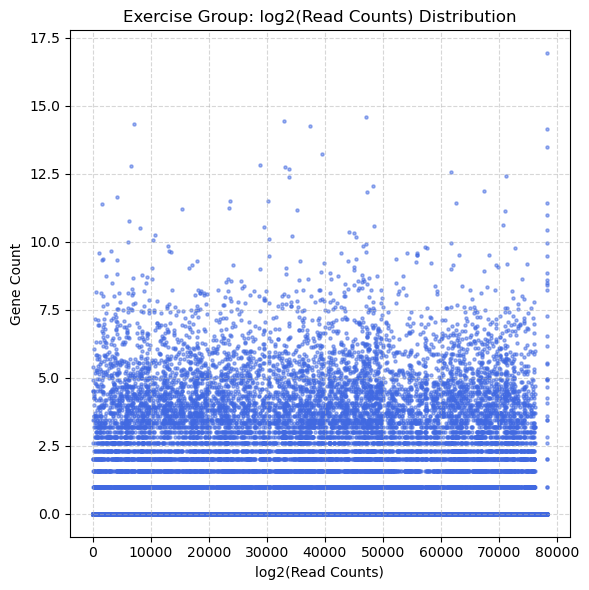

In [2]:
# Exercise 그룹 데이터 로드
exercise_counts = pd.read_csv("SRR2057648_read_counts.txt", sep='\t', comment='#', index_col=0)

# Read count 값 가져오기
exercise_vals = exercise_counts.iloc[:, -1].rename("exercise")

# 산점도 생성
plt.figure(figsize=(6, 6))
plt.scatter(range(len(exercise_vals)), np.log2(exercise_vals + 1), s=5, alpha=0.5, color='royalblue')
plt.title("Exercise Group: log2(Read Counts) Distribution")
plt.xlabel("log2(Read Counts)")
plt.ylabel("Gene Count")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [3]:
#Exercise ✅ 16. featureCounts 결과를 pandas로 읽기
import pandas as pd
exercise_counts = pd.read_csv("SRR2057648_read_counts.txt", sep='\t', comment='#', index_col=0)
exercise_counts.head()

,Chr,Start,End,Strand,Length,SRR2057648_1.mapped.sorted.bam
Geneid,,,,,,
ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0
ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0
ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,0
ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,0
ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0


In [4]:
#Exercise ✅ 16. featureCounts 결과를 pandas로 읽기
import pandas as pd
exercise_counts = pd.read_csv("SRR2057646_read_counts.txt", sep='\t', comment='#', index_col=0)
exercise_counts.head()

,Chr,Start,End,Strand,Length,SRR2057646_1.mapped.sorted.bam
Geneid,,,,,,
ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0
ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0
ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,0
ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,0
ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0


In [5]:
## 두 그룹 간의 리보솜 밀도(Ribosome Density)의 차이 분석 ##

# ✅ 1. 두 그룹의 count 데이터 병합
#두 그룹의 count 데이터 불러오기
exercise_df = pd.read_csv("SRR2057648_read_counts.txt", sep='\t', comment='#', index_col=0)
control_df = pd.read_csv("SRR2057646_read_counts.txt", sep='\t', comment='#', index_col=0)

In [6]:
#필요한 컬럼만 추출 (read count만 가져오기)
exercise_counts = exercise_df.iloc[:, -1].rename("exercise")
control_counts = control_df.iloc[:, -1].rename("control")

In [7]:
#공통된 gene ID 기준으로 merge
merged_counts = pd.concat([exercise_counts, control_counts], axis=1)

In [8]:
#결측치 제거 (양쪽에 다 있는 유전자만 사용)
merged_counts = merged_counts.dropna()

In [9]:
#결과 확인
display(merged_counts.head())

,exercise,control
Geneid,,
ENSMUSG00000102693.2,0,0
ENSMUSG00000064842.3,0,0
ENSMUSG00000051951.6,0,0
ENSMUSG00000102851.2,0,0
ENSMUSG00000103377.2,0,0


In [10]:
# ✅ 2. Count normalization (CPM(Counts Per Million)방식: GPT가 추천)

# 각 조건별 total read 수 계산
total_exercise = merged_counts["exercise"].sum()
total_control = merged_counts["control"].sum()

In [11]:
# CPM 계산
merged_cpm = merged_counts.copy()
merged_cpm["CPM_exercise"] = merged_counts["exercise"] / total_exercise * 1e6
merged_cpm["CPM_control"] = merged_counts["control"] / total_control * 1e6

In [12]:
#결과 확인
display(merged_cpm[["CPM_exercise", "CPM_control"]].head())

,CPM_exercise,CPM_control
Geneid,,
ENSMUSG00000102693.2,0.0,0.0
ENSMUSG00000064842.3,0.0,0.0
ENSMUSG00000051951.6,0.0,0.0
ENSMUSG00000102851.2,0.0,0.0
ENSMUSG00000103377.2,0.0,0.0


In [13]:
# ✅ 3. 로그 변환 (log2(CPM + 1)) : scatter plot을 그릴 때 log scale로 봐야 편함

# log2 변환하여 새로운 열 추가
import numpy as np

merged_cpm["log2_CPM_exercise"] = np.log2(merged_cpm["CPM_exercise"] + 1)
merged_cpm["log2_CPM_control"] = np.log2(merged_cpm["CPM_control"] + 1)

In [14]:
#결과 확인
display(merged_cpm[["log2_CPM_exercise", "log2_CPM_control"]].head())

,log2_CPM_exercise,log2_CPM_control
Geneid,,
ENSMUSG00000102693.2,0.0,0.0
ENSMUSG00000064842.3,0.0,0.0
ENSMUSG00000051951.6,0.0,0.0
ENSMUSG00000102851.2,0.0,0.0
ENSMUSG00000103377.2,0.0,0.0


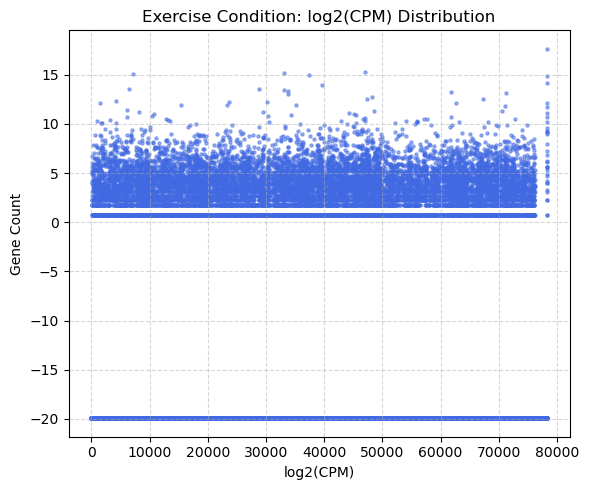

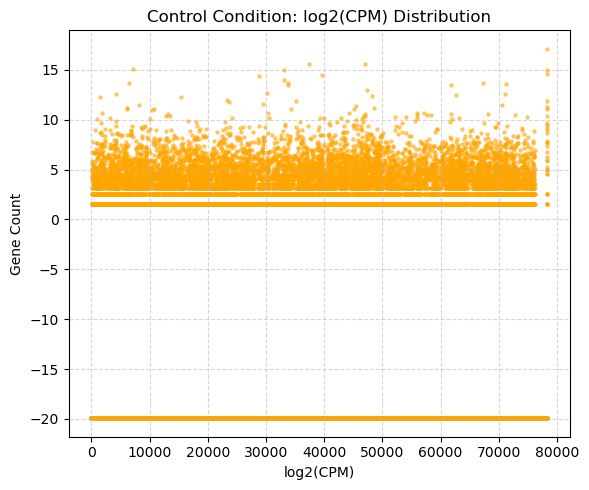

In [15]:
# ✅ 4. Scatter plot (각 조건별 발현량)

import matplotlib.pyplot as plt
import numpy as np

# 로그 변환 (0 회피용)
merged_cpm['log2_CPM_exercise'] = np.log2(merged_cpm['CPM_exercise'] + 1e-6)
merged_cpm['log2_CPM_control'] = np.log2(merged_cpm['CPM_control'] + 1e-6)

# 산점도: Exercise
plt.figure(figsize=(6, 5))
plt.scatter(range(len(merged_cpm)), merged_cpm['log2_CPM_exercise'], s=5, alpha=0.5, color='royalblue')
#plt.hist(merged_cpm['log2_CPM_exercise'], bins=100, color='royalblue', alpha=0.7)
plt.title("Exercise Condition: log2(CPM) Distribution")
plt.xlabel("log2(CPM)")
plt.ylabel("Gene Count")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 산점도: Control
plt.figure(figsize=(6, 5))
plt.scatter(range(len(merged_cpm)), merged_cpm['log2_CPM_control'], s=5, alpha=0.5, color='orange')
# plt.hist(merged_cpm['log2_CPM_control'], bins=100, color='orange', alpha=0.7)
plt.title("Control Condition: log2(CPM) Distribution")
plt.xlabel("log2(CPM)")
plt.ylabel("Gene Count")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

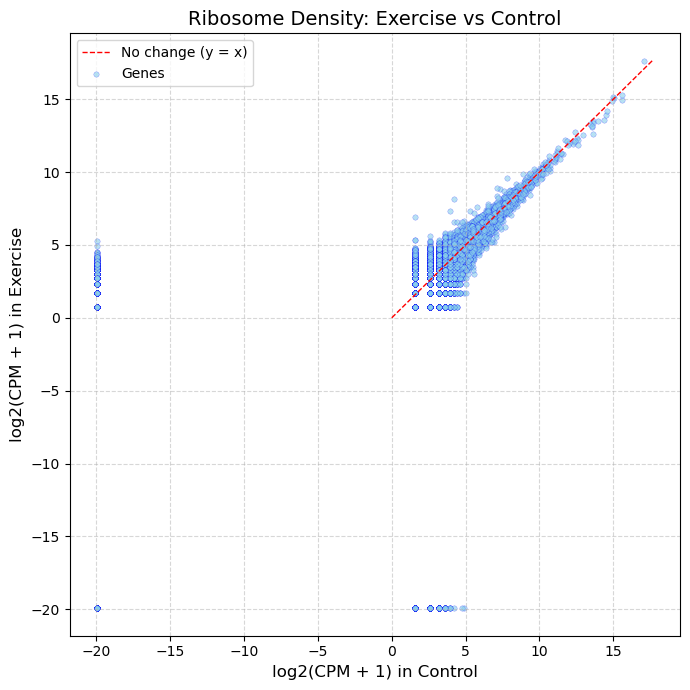

In [17]:
# ✅ 4. Scatter plot (Exercise vs Control) 
# y>x 부분은 운동 후 리보솜 밀도가 증가한 유전자   y<x 부분은 운동 후 리보솜 밀도가 감소한 유자자

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

max_val = max(merged_cpm["log2_CPM_control"].max(), merged_cpm["log2_CPM_exercise"].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=1, label='No change (y = x)')

plt.scatter(
    merged_cpm["log2_CPM_control"],
    merged_cpm["log2_CPM_exercise"],
    s=15, alpha=0.6, edgecolor='blue', linewidth=0.2, color='skyblue', label='Genes'
)

plt.xlabel("log2(CPM + 1) in Control", fontsize=12)
plt.ylabel("log2(CPM + 1) in Exercise", fontsize=12)
plt.title("Ribosome Density: Exercise vs Control", fontsize=14)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [18]:
#✅ 5. 리보솜 밀도 Fold change 계산 :Exercise 조건의 리보솜 밀도 / Control 조건의 리보솜 밀도 = 운동을 했을 때 리보솜이 얼마나 붙었는지 수치화 (어떤 유전자가 운동에 반응해서 단백질 합성이 증가/감소했는지 확인하기 위함)

#CPM 데이터 기준으로 rden_change 계산 (Exercise / Control)
merged_cpm["rden_change"] = merged_cpm["CPM_exercise"] / (merged_cpm["CPM_control"] + 1e-6)

In [19]:
# 2. log2로 변환 :시각화하기 좋게
merged_cpm['log2_rden_change'] = np.log2(merged_cpm['rden_change'])

/home/moon/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [20]:
#결과 확인
merged_cpm[['CPM_exercise', 'CPM_control', 'log2_rden_change']].head()

,CPM_exercise,CPM_control,log2_rden_change
Geneid,,,
ENSMUSG00000102693.2,0.0,0.0,-inf
ENSMUSG00000064842.3,0.0,0.0,-inf
ENSMUSG00000051951.6,0.0,0.0,-inf
ENSMUSG00000102851.2,0.0,0.0,-inf
ENSMUSG00000103377.2,0.0,0.0,-inf


In [21]:
# 3. 상위/하위 fold change 유전자 추출 (예: 2배 이상 증가/감소)
upregulated = merged_cpm[merged_cpm['log2_rden_change'] > 1]
downregulated = merged_cpm[merged_cpm['log2_rden_change'] < -1]

print(f"Upregulated genes (log2FC > 1): {len(upregulated)}")
print(f"Downregulated genes (log2FC < -1): {len(downregulated)}")

Upregulated genes (log2FC > 1): 3926
Downregulated genes (log2FC < -1): 66624


In [22]:
#✅ 6.localization 정보 결합을 위한 전처리

#localization 정보있는 파일 (Uniplot 사이트에서 Mus musculus(mouse) 검색 후 두 가지 column으로 선택해서 다운받음: Gene names  subcellular location)
!gunzip uniprotkb_Mus_musculus_Mouse_2025_06_05.tsv.gz

gzip: uniprotkb_Mus_musculus_Mouse_2025_06_05.tsv.gz: No such file or directory


In [24]:
# 컬럼 확인
import pandas as pd

uniprot_df = pd.read_csv("uniprotkb_Mus_musculus_Mouse_2025_06_05.tsv", sep='\t')

print(uniprot_df.columns)
uniprot_df.head()

Index(['Entry', 'Gene Names', 'Subcellular location [CC]'], dtype='object')


,Entry,Gene Names,Subcellular location [CC]
0,A0A023T699,NaN,SUBCELLULAR LOCATION: Host cytoplasmic vesicle...
1,A0A075F5C6,Hsf1,SUBCELLULAR LOCATION: Nucleus {ECO:0000256|ARB...
2,A0A087WPF7,Auts2 Kiaa0442,SUBCELLULAR LOCATION: Nucleus {ECO:0000269|Pub...
3,A0A087WPT2,Ptgs2,SUBCELLULAR LOCATION: Nucleus inner membrane {...
4,A0A087WRK1,Gm20905 Gm20814 Gm20835 Gm20850 Gm20855 Gm2086...,NaN


In [25]:
#필요한 열만 추출하고, 'Gene Names'에서 첫 번째 심볼만 사용
uniprot_genes = uniprot_df[['Gene Names', 'Subcellular location [CC]']].copy()
uniprot_genes.rename(columns={'Gene Names': 'symbol'}, inplace=True)
uniprot_genes['symbol'] = uniprot_genes['symbol'].str.split().str[0]

In [26]:
from mygene import MyGeneInfo
import pandas as pd

mg = MyGeneInfo()
ensembl_ids = merged_cpm.index.tolist()

# Ensembl 버전 (.1, .2 등)을 제거한 순수 ID만 추출
ensembl_ids_simple = [eid.split('.')[0] for eid in ensembl_ids]

# 조회
symbol_map = mg.querymany(ensembl_ids_simple, scopes='ensembl.gene', fields='symbol', species='mouse')

# 결과 미리보기
symbol_map[:5]

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
6 input query terms found dup hits:	[('ENSMUSG00000106441', 2), ('ENSMUSG00000072694', 2), ('ENSMUSG00000112376', 2), ('ENSMUSG000001152
75 input query terms found no hit:	['ENSMUSG00000144281', 'ENSMUSG00000144247', 'ENSMUSG00000144272', 'ENSMUSG00000144256', 'ENSMUSG000


[{'query': 'ENSMUSG00000102693',
  '_id': 'ENSMUSG00000102693',
  '_score': 27.559095,
  'symbol': '4933401J01Rik'},
 {'query': 'ENSMUSG00000064842',
  '_id': '115487594',
  '_score': 27.559095,
  'symbol': 'Gm26206'},
 {'query': 'ENSMUSG00000051951',
  '_id': '497097',
  '_score': 27.559095,
  'symbol': 'Xkr4'},
 {'query': 'ENSMUSG00000102851',
  '_id': '100418032',
  '_score': 10.599652,
  'symbol': 'Gm18956'},
 {'query': 'ENSMUSG00000103377',
  '_id': 'ENSMUSG00000103377',
  '_score': 27.559095,
  'symbol': 'Gm37180'}]

In [27]:
# 유효한 결과만 추출
symbol_map_valid = [entry for entry in symbol_map if 'symbol' in entry and 'query' in entry]

# DataFrame 변환
symbol_df = pd.DataFrame(symbol_map_valid)[['query', 'symbol']].drop_duplicates().set_index('query')

# merged_cpm에 Ensembl ID에서 버전 제거한 index로 일치시키기
merged_cpm = merged_cpm.copy()
merged_cpm.index = merged_cpm.index.str.split('.').str[0]

# 병합
merged_cpm = merged_cpm.merge(symbol_df, left_index=True, right_index=True)

In [28]:
#✅ 7. localization 정보 병합 및 시각화

# merged_cpm과 uniprot localization 정보를 symbol 기준으로 병합
merged_cpm_with_loc = merged_cpm.merge(uniprot_genes, on='symbol', how='left')

# 결과 확인
merged_cpm_with_loc[['symbol', 'CPM_exercise', 'CPM_control', 'log2_rden_change', 'Subcellular location [CC]']].head()

,symbol,CPM_exercise,CPM_control,log2_rden_change,Subcellular location [CC]
0,4933401J01Rik,0.0,0.0,-inf,NaN
1,Gm26206,0.0,0.0,-inf,NaN
2,Xkr4,0.0,0.0,-inf,SUBCELLULAR LOCATION: Cell membrane {ECO:00002...
3,Xkr4,0.0,0.0,-inf,NaN
4,Gm18956,0.0,0.0,-inf,NaN


<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_534/3154849848.py:37: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Control ($\log_2$ CPM)', fontsize=12)
/tmp/ipykernel_534/3154849848.py:38: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('Exercise ($\log_2$ CPM)', fontsize=12)


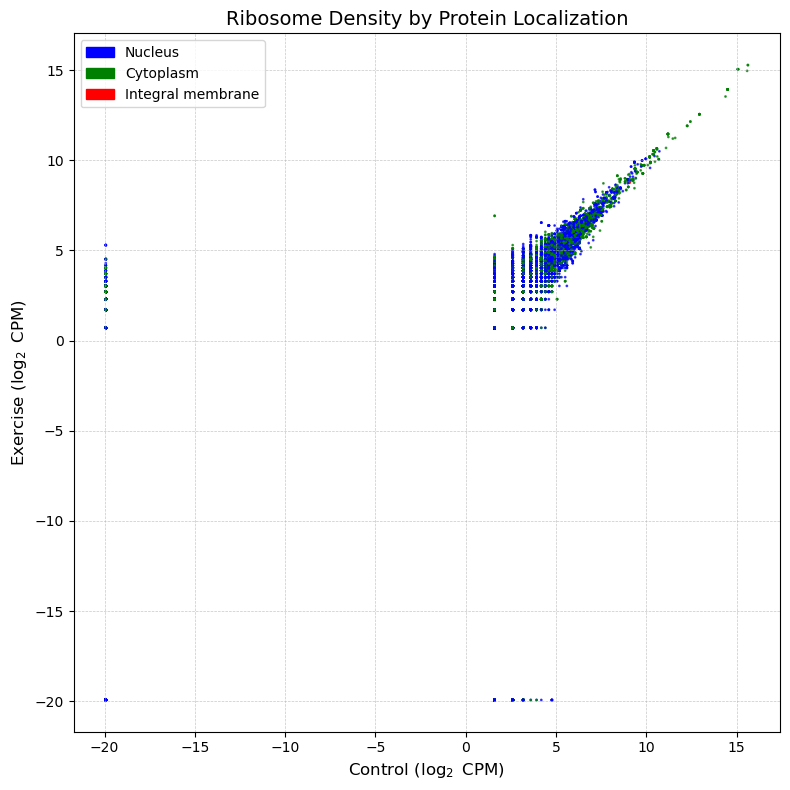

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 주요 위치 선정 (원하는 localization만 골라서 필터링 가능)
selected_localizations = ['nucleus', 'cytoplasm', 'integral membrane']

# 선택된 localization만 포함하도록 필터링
filtered = merged_cpm_with_loc[
    merged_cpm_with_loc['Subcellular location [CC]']
    .str.contains('|'.join(selected_localizations), case=False, na=False)
].copy()

# 'type' 컬럼 생성: localization 요약 정보 (첫 번째로 매칭되는 것만)
def match_loc(text):
    for loc in selected_localizations:
        if loc in text.lower():
            return loc
    return 'other'

filtered['type'] = filtered['Subcellular location [CC]'].apply(match_loc)

# 색상 매핑
palette = {'nucleus': 'blue', 'cytoplasm': 'green', 'integral membrane': 'red'}
colors = filtered['type'].map(palette)

# 스캐터 플롯
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    filtered['log2_CPM_control'],
    filtered['log2_CPM_exercise'],
    c=colors, s=1, alpha=0.7
)

# 레이블 및 제목
ax.set_xlabel('Control ($\log_2$ CPM)', fontsize=12)
ax.set_ylabel('Exercise ($\log_2$ CPM)', fontsize=12)
ax.set_title('Ribosome Density by Protein Localization', fontsize=14)

# 그리드
ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, alpha=0.7)

# 범례
legend_handles = [
    mpatches.Patch(color='blue', label='Nucleus'),
    mpatches.Patch(color='green', label='Cytoplasm'),
    mpatches.Patch(color='red', label='Integral membrane')
]
ax.legend(handles=legend_handles, loc='best')

# 레이아웃 정리 및 표시
plt.tight_layout()
plt.show()

<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_534/924942887.py:41: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Control $\log_2$(CPM)', fontsize=12)
/tmp/ipykernel_534/924942887.py:42: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('Ribosome density change $\log_2$(Exercise / Control)', fontsize=12)


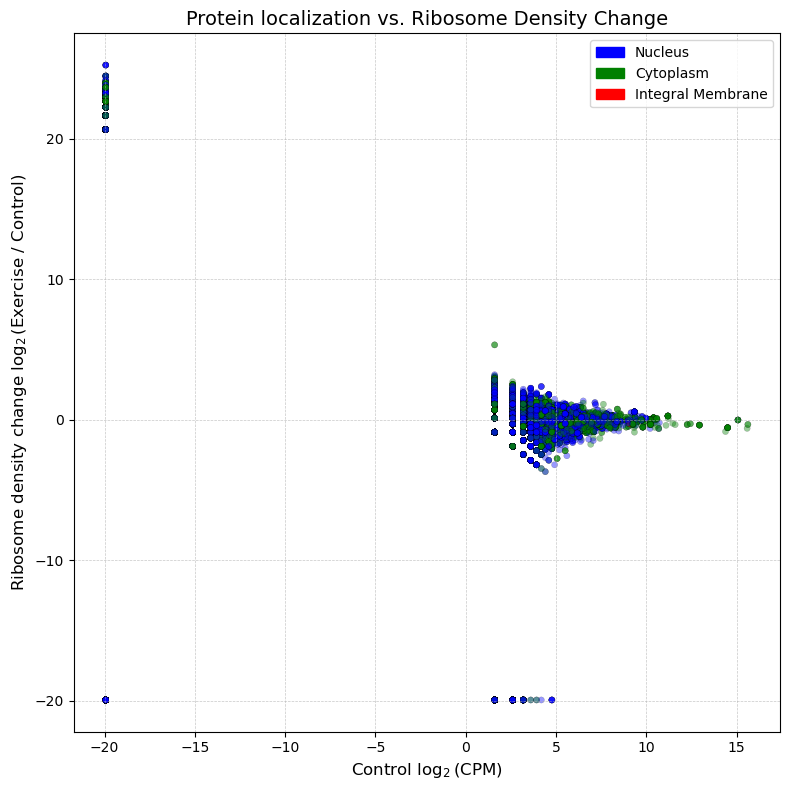

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 주요 위치 선정 (원하는 localization만 골라서 필터링 가능)
selected_localizations = ['nucleus', 'cytoplasm', 'integral membrane']

# 선택된 localization만 포함하도록 필터링
filtered = merged_cpm_with_loc[
    merged_cpm_with_loc['Subcellular location [CC]']
    .str.contains('|'.join(selected_localizations), case=False, na=False)
].copy()

# 'type' 컬럼 생성: localization 요약 정보 (첫 번째로 매칭되는 것만)
def match_loc(text):
    for loc in selected_localizations:
        if loc in text.lower():
            return loc
    return 'other'

filtered['type'] = filtered['Subcellular location [CC]'].apply(match_loc)

# 로그 변환
filtered['log2_rden_change'] = np.log2(filtered['rden_change'] + 1e-6)  # 0 회피용
filtered['log2_CPM_control'] = np.log2(filtered['CPM_control'] + 1e-6)

# 개선된 시각화: 점 크기 키우고 투명도 낮추기, 겹침 줄이기
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    filtered['log2_CPM_control'],
    filtered['log2_rden_change'],
    c=colors,
    s=20,              # 점 크기: 5 → 20
    alpha=0.4,         # 투명도 낮춤: 0.7 → 0.4
    edgecolor='k',     # 테두리 색 추가
    linewidth=0.2      # 테두리 두께
)

# 레이블 및 제목
ax.set_xlabel('Control $\log_2$(CPM)', fontsize=12)
ax.set_ylabel('Ribosome density change $\log_2$(Exercise / Control)', fontsize=12)
ax.set_title('Protein localization vs. Ribosome Density Change', fontsize=14)

# 그리드 및 범례
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
legend_handles = [mpatches.Patch(color=palette[key], label=key.title()) for key in palette]
ax.legend(handles=legend_handles, loc='best')

plt.tight_layout()
plt.show()